# SA_Global
## This code concat the Global SA dfs from pickles and creates Plots

## Imports

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Functions

In [2]:
def plot_response_surface(global_sa_df, plot_factor1, plot_factor2, const_factor1, const_factor2):
    # Define your levels
    max_runoff_levels = np.linspace(0, 45, 23)  # Adjusted levels for max runoff
    total_runoff_levels = np.linspace(5000, 160000, 21)  # Adjusted levels for total runoff

    # Create subplots
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey='row')

    # Find the two closest values to 0 for each constant factor
    const_factor1_values = global_sa_df[const_factor1].unique()
    const_factor2_values = global_sa_df[const_factor2].unique()
    const_factor1_values.sort()
    const_factor2_values.sort()

    # Select the smallest absolute value between the maximum and minimum values
    const_factor1_min = min(const_factor1_values, key=abs)
    const_factor2_min = min(const_factor2_values, key=abs)

    # Filter DataFrame based on the closest values to 0 for constant factors
    cons_factors_df = global_sa_df[
        (global_sa_df[const_factor1] == const_factor1_min) &
        (global_sa_df[const_factor2] == const_factor2_min)
    ]
    print(f'{const_factor1} =  {const_factor1_min}, {const_factor2} =  {const_factor2_min}')
    # Axis
    x_axis = cons_factors_df[plot_factor1].values
    y_axis = cons_factors_df[plot_factor2].values

    # Contour
    max_runoff_const = cons_factors_df['swmm_max_runoff']
    total_runoff_const = cons_factors_df['swmm_total_runoff']

    # Plot for imp_change and max_rainfall_change (Max Runoff Bias)
    contour1 = axs[0].tricontourf(x_axis, y_axis, max_runoff_const, cmap='RdBu_r', levels=max_runoff_levels)
    contour_lines1 = axs[0].tricontour(x_axis, y_axis, max_runoff_const, colors='k', levels=max_runoff_levels)
    cbar1 = fig.colorbar(contour1, ax=axs[0])
    cbar1.ax.tick_params(labelsize=12)  # Adjust colorbar font size
    cbar1.set_label('Max Runoff (m³/s)', fontsize=14)
    cbar1.add_lines(contour_lines1)
    cbar1.set_ticks(max_runoff_levels)
    cbar1.set_ticklabels([f'{int(level)}' for level in max_runoff_levels])  # Integer tick labels
    axs[0].set_xlabel(f'{plot_factor1} (%)', fontsize=14)
    axs[0].set_ylabel(f'{plot_factor2} (%)', fontsize=14)
    axs[0].set_title('Max Runoff', fontsize=20, fontweight='bold')  
    axs[0].tick_params(axis='both', which='major', labelsize=12)
    axs[0].grid(True)

    # Plot for imp_change and max_rainfall_change (Total Runoff Bias)
    contour2 = axs[1].tricontourf(x_axis, y_axis, total_runoff_const, cmap='RdBu_r', levels=total_runoff_levels)
    contour_lines2 = axs[1].tricontour(x_axis, y_axis, total_runoff_const, colors='k', levels=total_runoff_levels)
    cbar2 = fig.colorbar(contour2, ax=axs[1])
    cbar2.ax.tick_params(labelsize=12)  # Adjust colorbar font size
    cbar2.set_label('Total Runoff (m³)', fontsize=14)
    cbar2.add_lines(contour_lines2)
    cbar2.set_ticks(total_runoff_levels)
    cbar2.set_ticklabels([f'{int(level)}' for level in total_runoff_levels])  # Integer tick labels
    axs[1].set_xlabel(f'{plot_factor1} (%)', fontsize=14)
    axs[1].set_title('Total Runoff', fontsize=20, fontweight='bold')  
    axs[1].tick_params(axis='both', which='major', labelsize=12)
    axs[1].grid(True)

    # Adjust layout
    plt.subplots_adjust(wspace=0.3)  # Adjust width space between subplots
    plt.tight_layout()


# Load Global SA dfs

In [3]:
# Directory containing the pickles
filename = '20191213'
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis/"
date = '_'.join([filename[:4], filename[4:6], filename[6:]])
sim_dir = os.path.join(sim_dir, date + '/')
pickle_dir = os.path.join(sim_dir, 'pickles')

# Retrieve all pickle files in the directory
pickle_files = glob.glob(os.path.join(pickle_dir, "global_sa_pickle*.pkl"))

# List to store loaded DataFrames
dfs = []

# Iterate through each pickle file
for pickle_file in pickle_files:
    # Load pickle into DataFrame
    df = pd.read_pickle(pickle_file)
    # Append to list
    dfs.append(df)
#     print(pickle_file)
# Concatenate all DataFrames in the list
combined_df = pd.concat(dfs, ignore_index=True)
del dfs

In [4]:
def plot_response_surface(global_sa_df, plot_factor1, plot_factor2, const_factor1, const_factor2, const_factor3, const_factor4):
    # Define your levels
    max_runoff_levels = np.linspace(0, 45, 23)  # Adjusted levels for max runoff
    total_runoff_levels = np.linspace(5000, 160000, 21)  # Adjusted levels for total runoff

    # Create subplots
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey='row')

    # Find the unique values for each constant factor
    const_factor1_values = global_sa_df[const_factor1].unique()
    const_factor2_values = global_sa_df[const_factor2].unique()
    const_factor3_values = global_sa_df[const_factor3].unique()
    const_factor4_values = global_sa_df[const_factor4].unique()

    # Select the smallest absolute value closest to 0 for each constant factor
    const_factor1_min = min(const_factor1_values, key=abs)
    const_factor2_min = min(const_factor2_values, key=abs)
    const_factor3_min = min(const_factor3_values, key=abs)
    const_factor4_min = min(const_factor4_values, key=abs)

    # Round the values to the desired precision (e.g., 5 decimal places)
    precision = 5
    const_factor1_min_rounded = round(const_factor1_min, precision)
    const_factor2_min_rounded = round(const_factor2_min, precision)
    const_factor3_min_rounded = round(const_factor3_min, precision)
    const_factor4_min_rounded = round(const_factor4_min, precision)

    # Round the DataFrame values for the same factors
    global_sa_df[const_factor1] = global_sa_df[const_factor1].round(precision)
    global_sa_df[const_factor2] = global_sa_df[const_factor2].round(precision)
    global_sa_df[const_factor3] = global_sa_df[const_factor3].round(precision)
    global_sa_df[const_factor4] = global_sa_df[const_factor4].round(precision)

    # Filter DataFrame based on the rounded values closest to 0 for constant factors
    cons_factors_df = global_sa_df[
        (global_sa_df[const_factor1] == const_factor1_min_rounded) &
        (global_sa_df[const_factor2] == const_factor2_min_rounded) &
        (global_sa_df[const_factor3] == const_factor3_min_rounded) &
        (global_sa_df[const_factor4] == const_factor4_min_rounded)
    ]

    print(f'{const_factor1} = {const_factor1_min_rounded}, {const_factor2} = {const_factor2_min_rounded}, {const_factor3} = {const_factor3_min_rounded}, {const_factor4} = {const_factor4_min_rounded}')

    # Axis
    x_axis = cons_factors_df[plot_factor1].values
    y_axis = cons_factors_df[plot_factor2].values

    # Contour
    max_runoff_const = cons_factors_df['swmm_max_runoff']
    total_runoff_const = cons_factors_df['swmm_total_runoff']

    # Plot for imp_change and max_rainfall_change (Max Runoff Bias)
    contour1 = axs[0].tricontourf(x_axis, y_axis, max_runoff_const, cmap='RdBu_r', levels=max_runoff_levels)
    contour_lines1 = axs[0].tricontour(x_axis, y_axis, max_runoff_const, colors='k', levels=max_runoff_levels)
    cbar1 = fig.colorbar(contour1, ax=axs[0])
    cbar1.ax.tick_params(labelsize=12)  # Adjust colorbar font size
    cbar1.set_label('Max Runoff (m³/s)', fontsize=14)
    cbar1.add_lines(contour_lines1)
    cbar1.set_ticks(max_runoff_levels)
    cbar1.set_ticklabels([f'{int(level)}' for level in max_runoff_levels])  # Integer tick labels
    axs[0].set_xlabel(f'{plot_factor1} (%)', fontsize=14, fontweight='bold')
    axs[0].set_ylabel(f'{plot_factor2} (%)', fontsize=14, fontweight='bold')
    axs[0].set_title('Max Runoff', fontsize=20, fontweight='bold')  
    axs[0].tick_params(axis='both', which='major', labelsize=12)
    axs[0].grid(True)

    # Plot for imp_change and max_rainfall_change (Total Runoff Bias)
    contour2 = axs[1].tricontourf(x_axis, y_axis, total_runoff_const, cmap='RdBu_r', levels=total_runoff_levels)
    contour_lines2 = axs[1].tricontour(x_axis, y_axis, total_runoff_const, colors='k', levels=total_runoff_levels)
    cbar2 = fig.colorbar(contour2, ax=axs[1])
    cbar2.ax.tick_params(labelsize=12)  # Adjust colorbar font size
    cbar2.set_label('Total Runoff (m³)', fontsize=14)
    cbar2.add_lines(contour_lines2)
    cbar2.set_ticks(total_runoff_levels)
    cbar2.set_ticklabels([f'{int(level)}' for level in total_runoff_levels])  # Integer tick labels
    axs[1].set_xlabel(f'{plot_factor1} (%)', fontsize=14, fontweight='bold')
    axs[1].set_title('Total Runoff', fontsize=20, fontweight='bold') 
    axs[1].tick_params(axis='both', which='major', labelsize=12)
    axs[1].grid(True)

    # Adjust layout
    plt.subplots_adjust(wspace=0.3)  # Adjust width space between subplots
    plt.tight_layout()


In [5]:
combined_df

,max_rainfall_change,imp_change,storage_change,n_change,cn_change,pct_zero_change,total_runoff_change_percent,swmm_total_runoff,swmm_max_runoff
0,-15.931541,-90.0,-80.0,0.0,-50.0,-90.0,-87.191060,11060.953992,1.859716
1,-15.931541,-90.0,-80.0,0.0,-50.0,40.0,-86.488520,11667.621283,1.859835
2,-15.931541,-90.0,-80.0,0.0,-50.0,-70.0,-87.082920,11154.336521,1.859237
3,-15.931541,-90.0,-80.0,0.0,750.0,-90.0,-87.191060,11060.953992,1.859716
4,-15.931541,-90.0,-80.0,0.0,750.0,40.0,-86.488520,11667.621283,1.859835
...,...,...,...,...,...,...,...,...,...
805,68.340147,30.0,700.0,0.0,750.0,40.0,23.599860,106732.668511,36.259743
806,68.340147,30.0,700.0,0.0,750.0,-70.0,-72.063668,24123.969816,7.297351
807,68.340147,30.0,700.0,0.0,100.0,-90.0,-90.743016,7993.719670,1.938581
808,68.340147,30.0,700.0,0.0,100.0,40.0,23.599860,106732.668511,36.259743


imp_change = 0.0, max_rainfall_change = -15.93154, cn_change = -50.0, n_change = 0.0


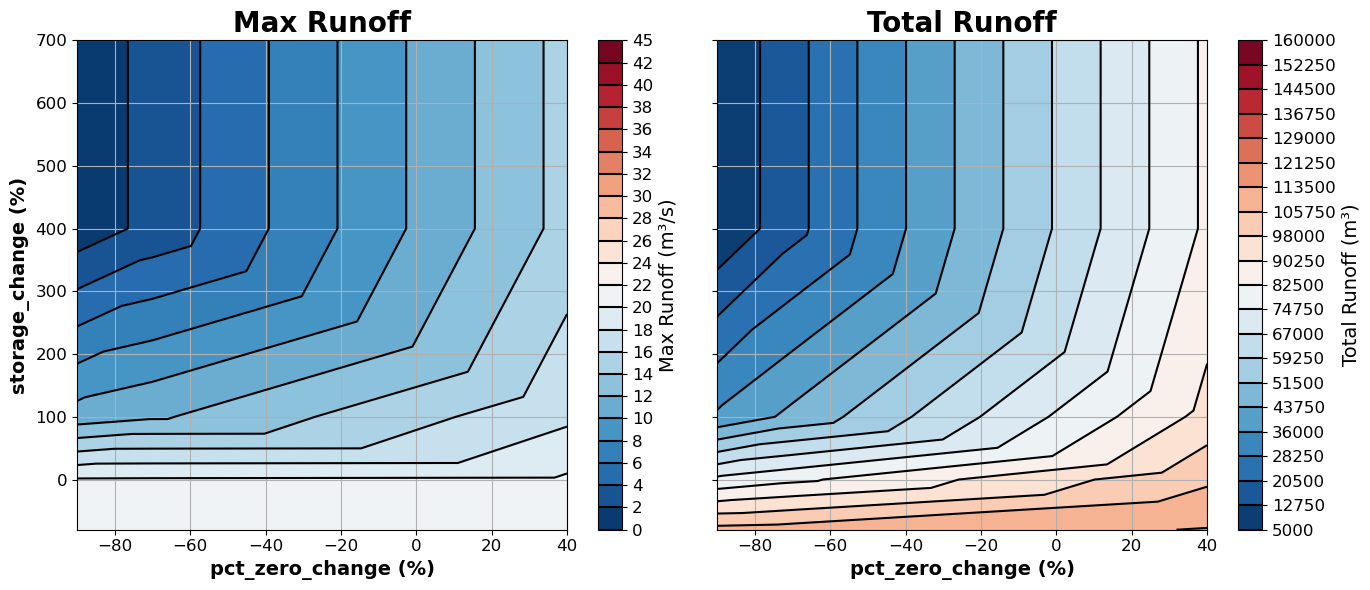

In [6]:
plot_response_surface(combined_df, 'pct_zero_change', 'storage_change', 'imp_change', 'max_rainfall_change', 'cn_change', 'n_change')

n_change = 0.0, storage_change = 0.0, cn_change = -50.0, pct_zero_change = 40.0


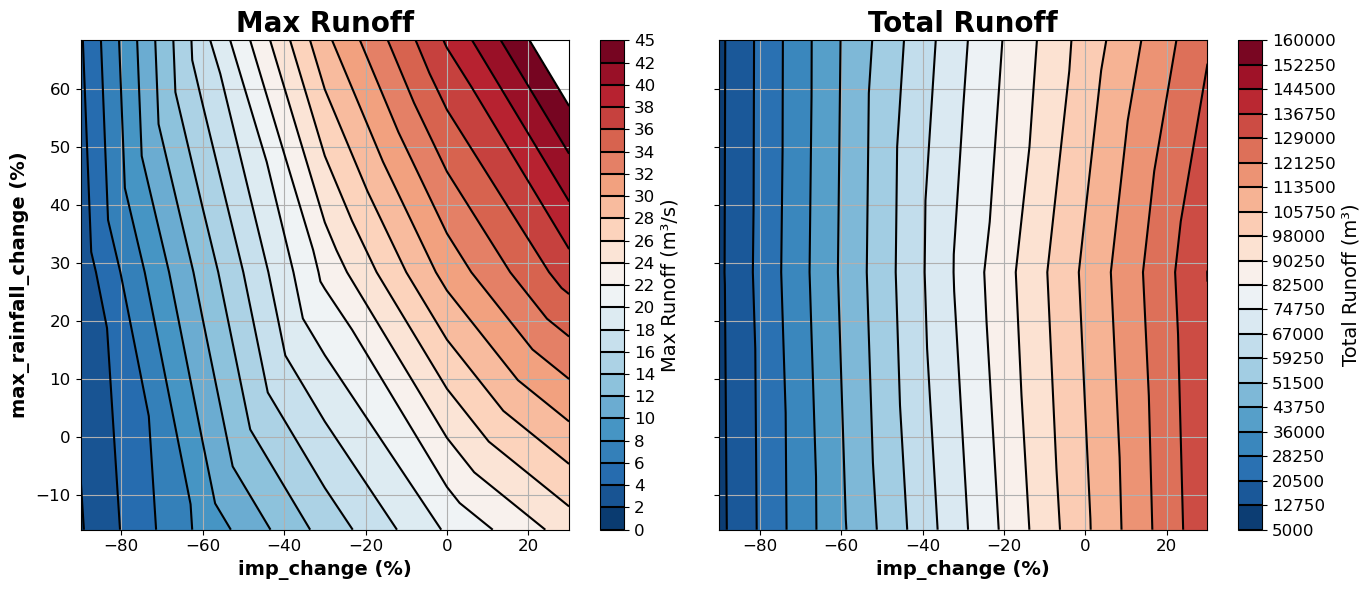

In [7]:
plot_response_surface(combined_df,'imp_change', 'max_rainfall_change', 'n_change', 'storage_change', 'cn_change', 'pct_zero_change')

In [8]:
# plot_response_surface(combined_df, 'n_change', 'pct_zero_change', 'imp_change', 'max_rainfall_change', 'storage_change', 'cn_change')

imp_change = 0.0, max_rainfall_change = -15.93154, pct_zero_change = 40.0, n_change = 0.0


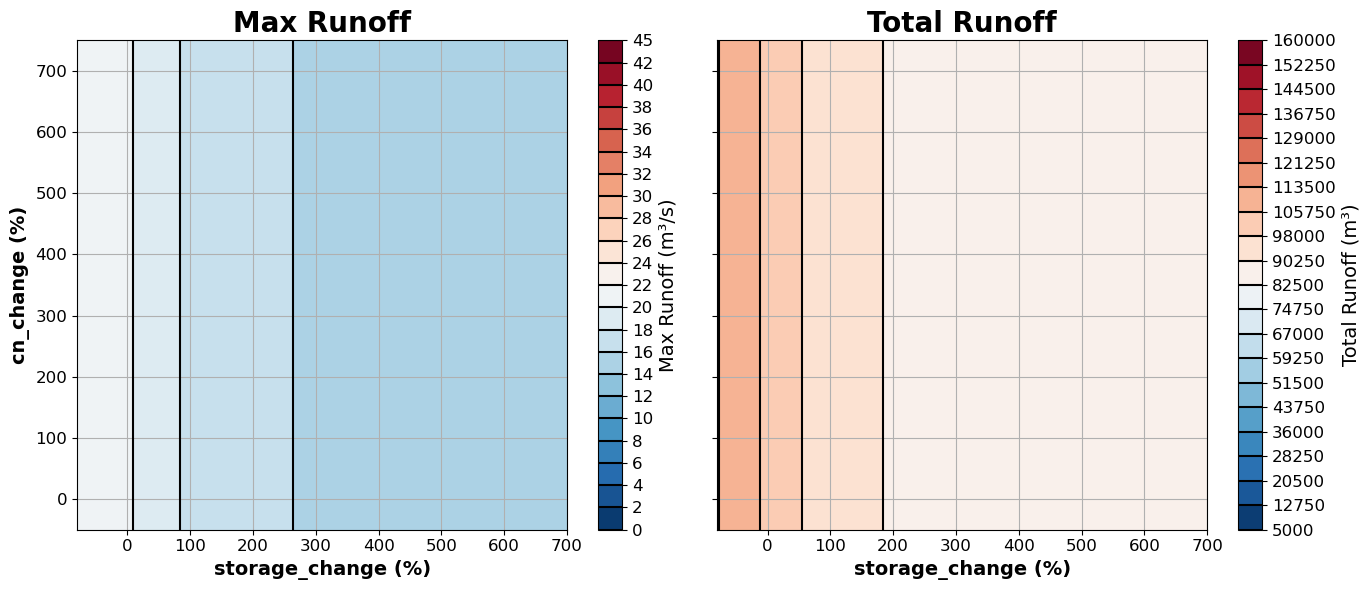

In [9]:
plot_response_surface(combined_df, 'storage_change', 'cn_change', 'imp_change', 'max_rainfall_change', 'pct_zero_change', 'n_change')

imp_change = 0.0, max_rainfall_change = -15.93154, storage_change = 0.0, n_change = 0.0


C:\Users\raznu\AppData\Local\Temp\ipykernel_18616\842734776.py:54: UserWarning: No contour levels were found within the data range.
  contour_lines1 = axs[0].tricontour(x_axis, y_axis, max_runoff_const, colors='k', levels=max_runoff_levels)


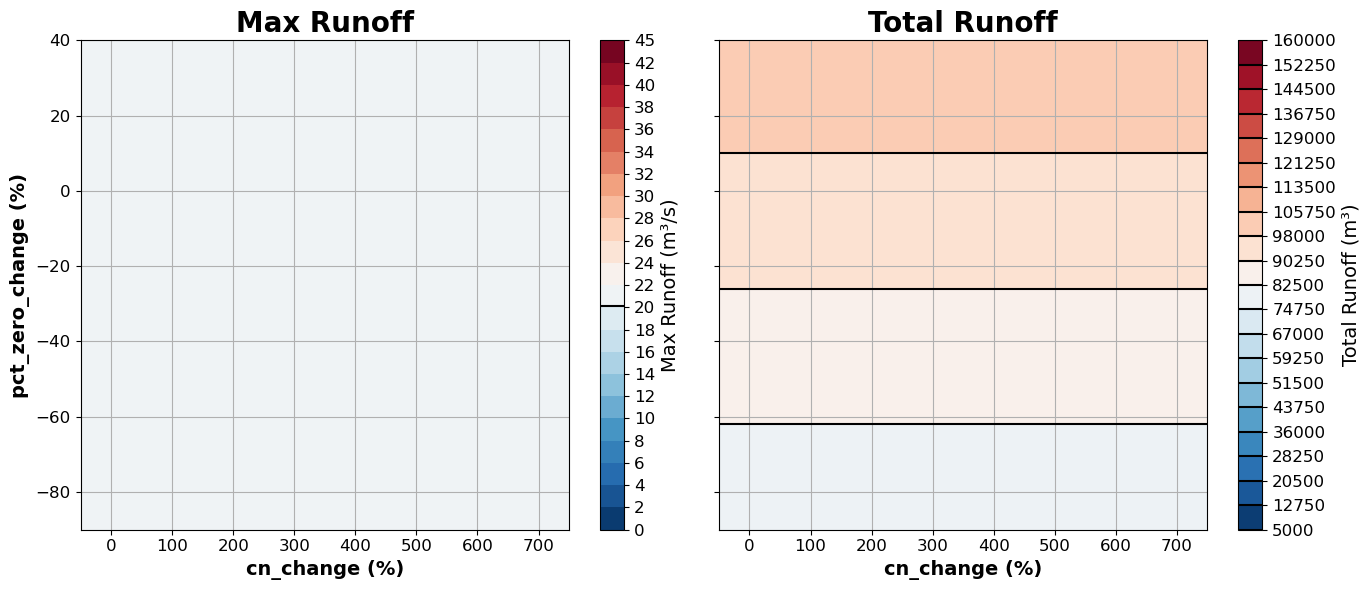

In [10]:
plot_response_surface(combined_df, 'cn_change', 'pct_zero_change', 'imp_change', 'max_rainfall_change', 'storage_change', 'n_change')

imp_change = 0.0, max_rainfall_change = -15.93154, storage_change = 0.0, n_change = 0.0


C:\Users\raznu\AppData\Local\Temp\ipykernel_18616\842734776.py:54: UserWarning: No contour levels were found within the data range.
  contour_lines1 = axs[0].tricontour(x_axis, y_axis, max_runoff_const, colors='k', levels=max_runoff_levels)


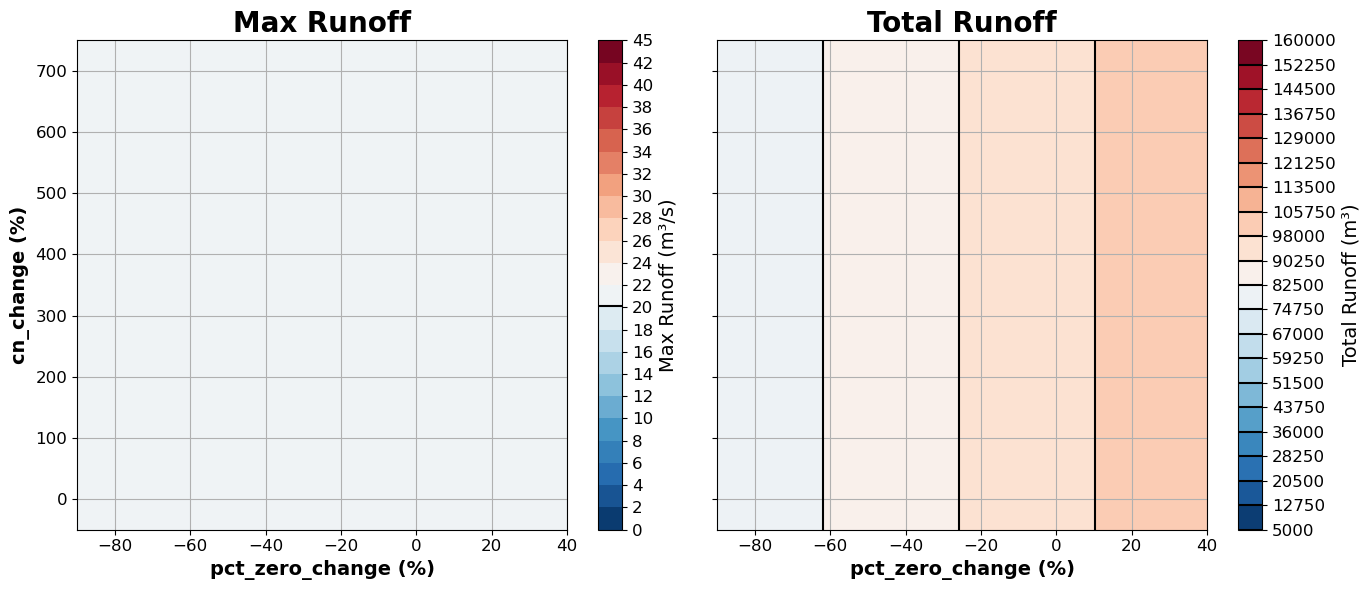

In [11]:
plot_response_surface(combined_df, 'pct_zero_change', 'cn_change', 'imp_change', 'max_rainfall_change', 'storage_change', 'n_change')


cn_change = -50.0, max_rainfall_change = -15.93154, storage_change = 0.0, n_change = 0.0


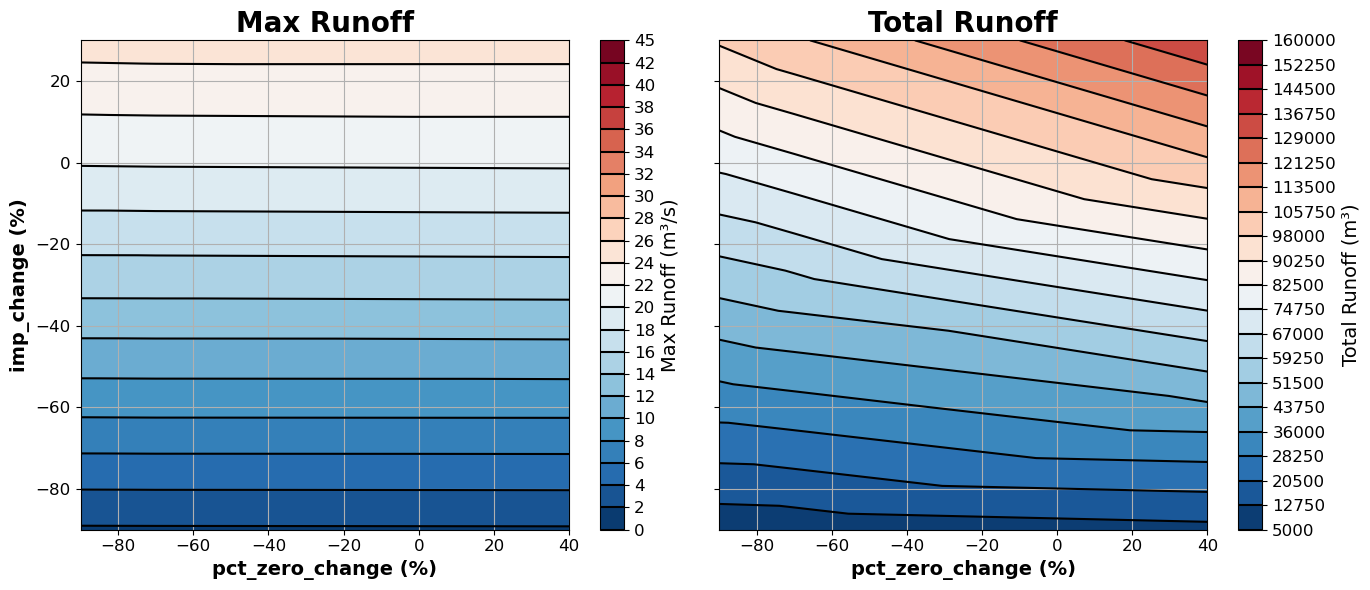

In [12]:
plot_response_surface(combined_df, 'pct_zero_change', 'imp_change', 'cn_change', 'max_rainfall_change', 'storage_change', 'n_change')

# smaller sample

In [13]:
def plot_response_surface(global_sa_df, plot_factor1, plot_factor2, const_factor1, const_factor2):
    # Define your levels
    max_runoff_levels = np.linspace(0, 45, 23)  # Adjusted levels for max runoff
    total_runoff_levels = np.linspace(5000, 160000, 21)  # Adjusted levels for total runoff

    # Create subplots
    fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey='row')

    # Find the two closest values to 0 for each constant factor
    const_factor1_values = global_sa_df[const_factor1].unique()
    const_factor2_values = global_sa_df[const_factor2].unique()
    const_factor1_values.sort()
    const_factor2_values.sort()

    # Select the smallest absolute value between the maximum and minimum values
    const_factor1_min = min(const_factor1_values, key=abs)
    const_factor2_min = min(const_factor2_values, key=abs)

    # Filter DataFrame based on the closest values to 0 for constant factors
    cons_factors_df = global_sa_df[
        (global_sa_df[const_factor1] == const_factor1_min) &
        (global_sa_df[const_factor2] == const_factor2_min)
    ]
    print(f'{const_factor1} =  {const_factor1_min}, {const_factor2} =  {const_factor2_min}')
    # Axis
    x_axis = cons_factors_df[plot_factor1].values
    y_axis = cons_factors_df[plot_factor2].values

    # Contour
    max_runoff_const = cons_factors_df['swmm_max_runoff']
    total_runoff_const = cons_factors_df['swmm_total_runoff']

    # Plot for imp_change and max_rainfall_change (Max Runoff Bias)
    contour1 = axs[0].tricontourf(x_axis, y_axis, max_runoff_const, cmap='RdBu_r', levels=max_runoff_levels)
    contour_lines1 = axs[0].tricontour(x_axis, y_axis, max_runoff_const, colors='k', levels=max_runoff_levels)
    cbar1 = fig.colorbar(contour1, ax=axs[0])
    cbar1.ax.tick_params(labelsize=12)  # Adjust colorbar font size
    cbar1.set_label('Max Runoff (m³/s)', fontsize=14)
    cbar1.add_lines(contour_lines1)
    cbar1.set_ticks(max_runoff_levels)
    cbar1.set_ticklabels([f'{int(level)}' for level in max_runoff_levels])  # Integer tick labels
    axs[0].set_xlabel(f'{plot_factor1} (%)', fontsize=14)
    axs[0].set_ylabel(f'{plot_factor2} (%)', fontsize=14)
    axs[0].set_title('Max Runoff', fontsize=20, fontweight='bold')  # Larger and bold title
    axs[0].tick_params(axis='both', which='major', labelsize=12)
    axs[0].grid(True)

    # Plot for imp_change and max_rainfall_change (Total Runoff Bias)
    contour2 = axs[1].tricontourf(x_axis, y_axis, total_runoff_const, cmap='RdBu_r', levels=total_runoff_levels)
    contour_lines2 = axs[1].tricontour(x_axis, y_axis, total_runoff_const, colors='k', levels=total_runoff_levels)
    cbar2 = fig.colorbar(contour2, ax=axs[1])
    cbar2.ax.tick_params(labelsize=12)  # Adjust colorbar font size
    cbar2.set_label('Total Runoff (m³)', fontsize=14)
    cbar2.add_lines(contour_lines2)
    cbar2.set_ticks(total_runoff_levels)
    cbar2.set_ticklabels([f'{int(level)}' for level in total_runoff_levels])  # Integer tick labels
    axs[1].set_xlabel(f'{plot_factor1} (%)', fontsize=14)
    axs[1].set_title('Total Runoff', fontsize=20, fontweight='bold')  # Larger and bold title
    axs[1].tick_params(axis='both', which='major', labelsize=12)
    axs[1].grid(True)

    # Adjust layout
    plt.subplots_adjust(wspace=0.3)  # Adjust width space between subplots
    plt.tight_layout()


In [14]:
# Load DataFrame from pickle file of 1500 values, dont use it after connecting the chunk dfs
global_sa_df = pd.read_pickle(r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Sensitivity_Analysis\global_sa_df.pkl")


# Time to Plot

n_change =  0.0, storage_change =  0.0


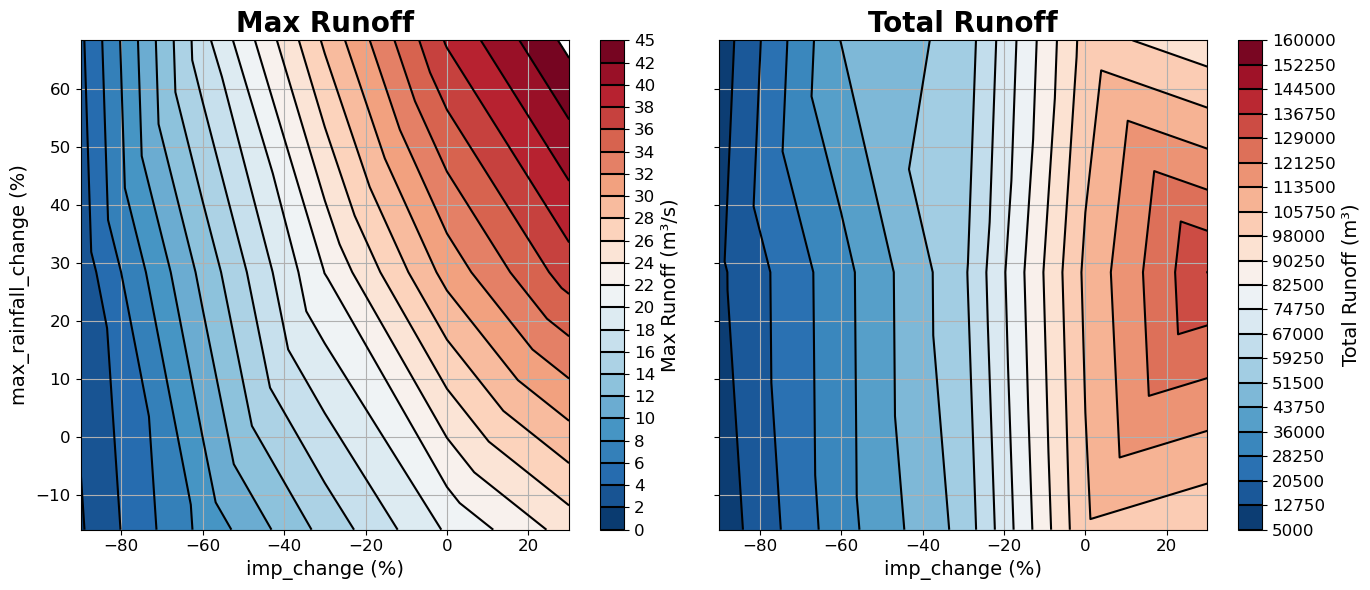

In [15]:
## Select from here:
factors = ['max_rainfall_change', 'imp_change', 'storage_change', 'n_change', 'cn_change', 'pct_zero_change']

# Example usage:
plot_response_surface(combined_df,'imp_change', 'max_rainfall_change', 'n_change', 'storage_change')


n_change =  0.0, max_rainfall_change =  -15.93154


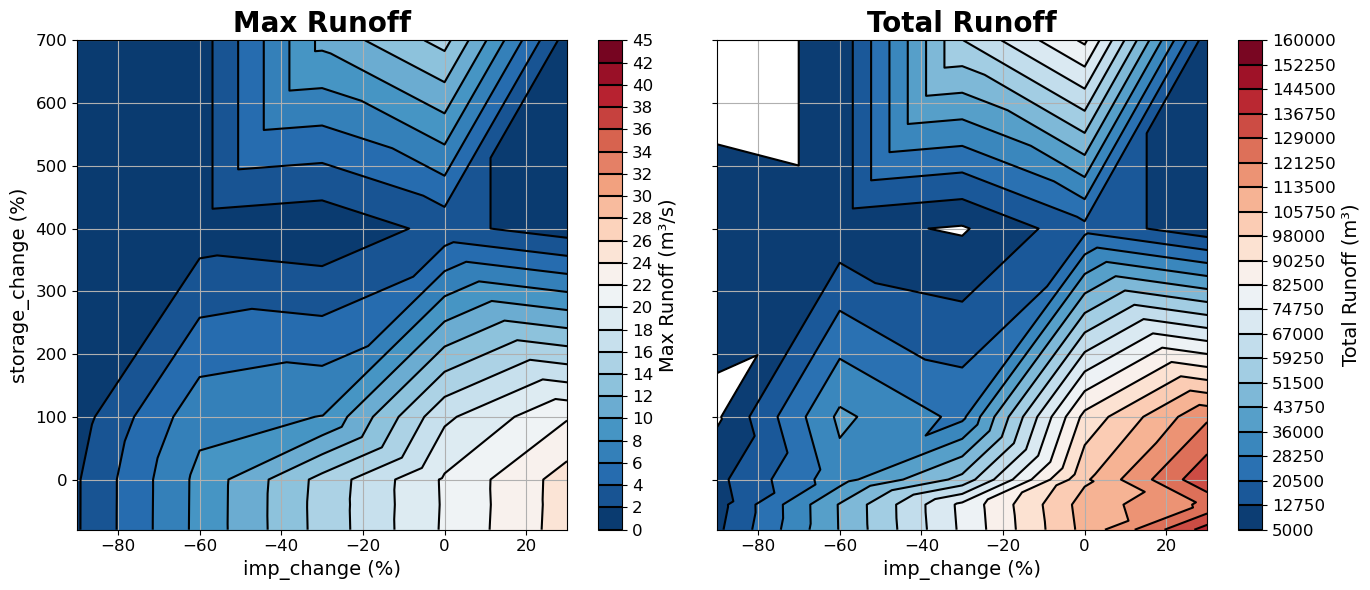

In [16]:
plot_response_surface(combined_df,'imp_change', 'storage_change', 'n_change', 'max_rainfall_change')

imp_change =  0.0, n_change =  0.0


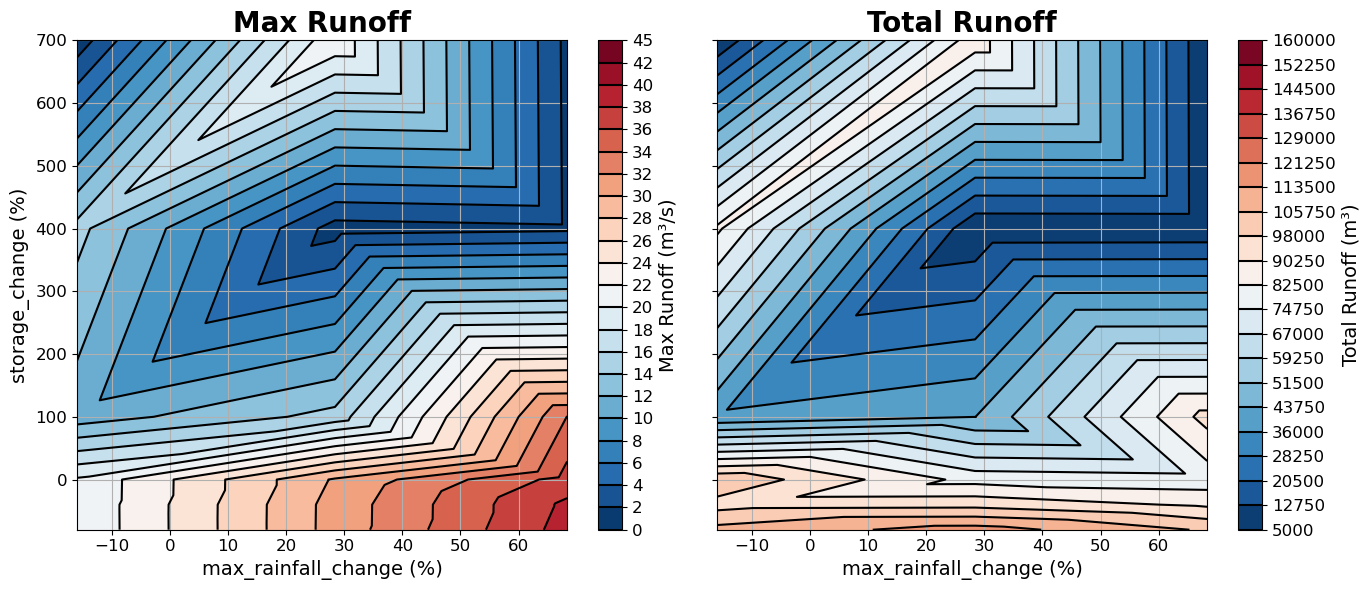

In [17]:
plot_response_surface(combined_df,'max_rainfall_change', 'storage_change', 'imp_change', 'n_change')

imp_change =  0.0, storage_change =  0.0


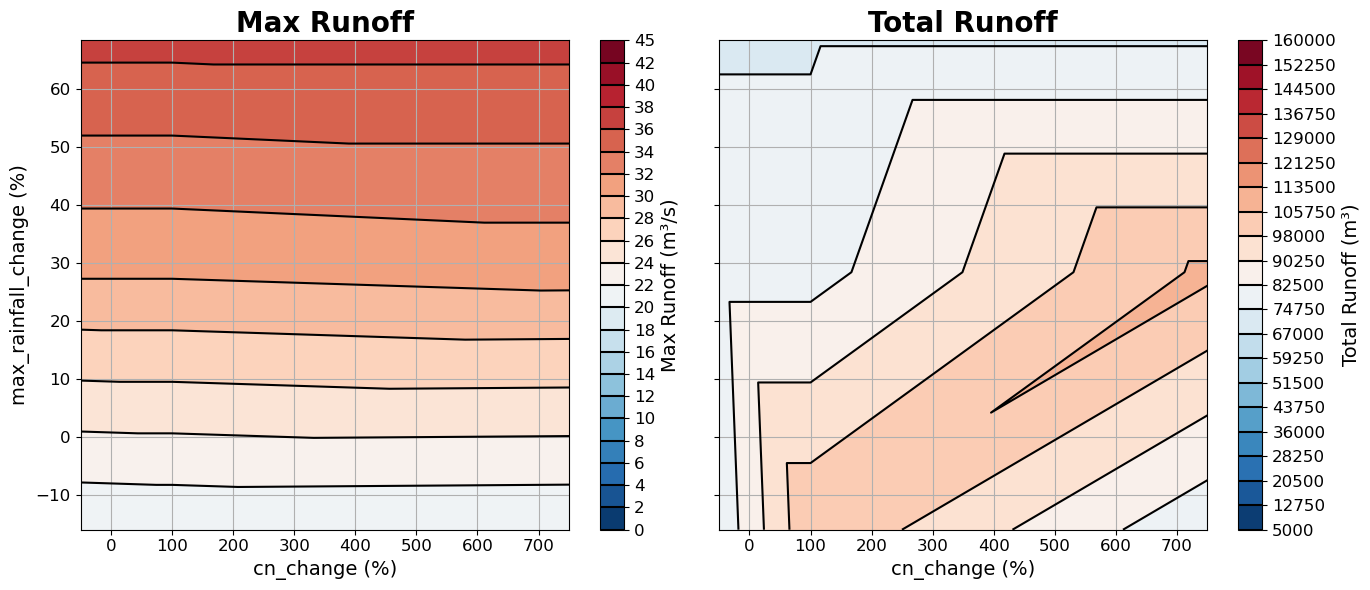

In [18]:
plot_response_surface(combined_df,'cn_change', 'max_rainfall_change', 'imp_change', 'storage_change')

max_rainfall_change =  -15.93154, imp_change =  0.0


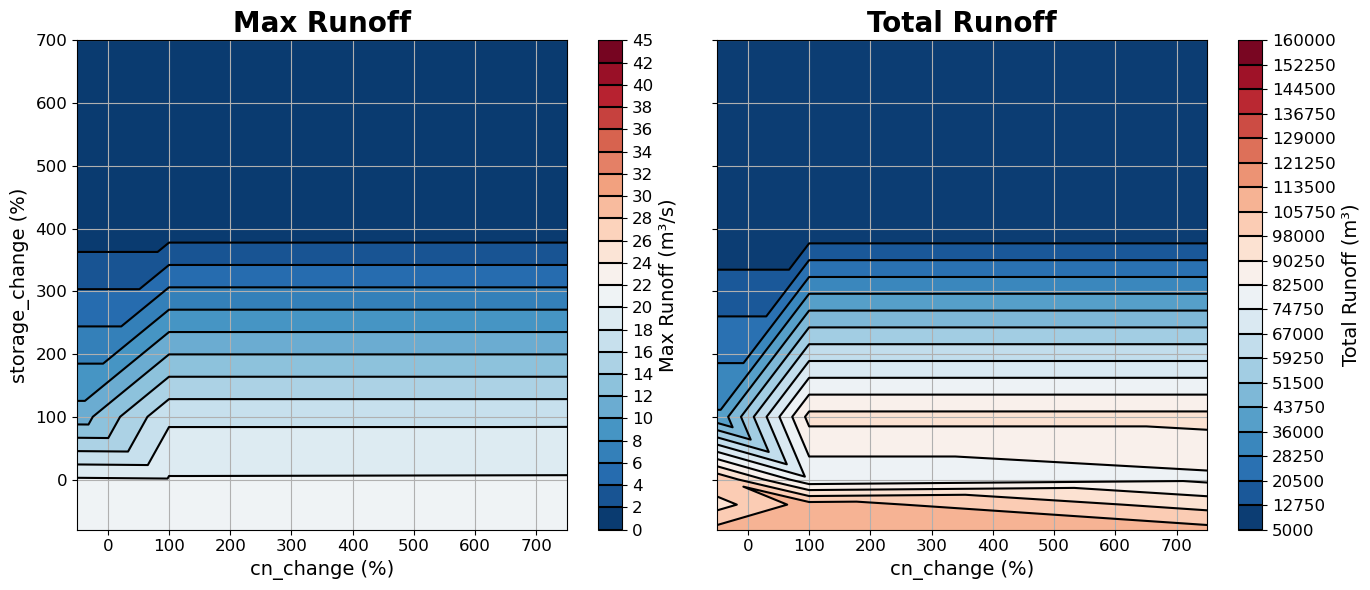

In [19]:
plot_response_surface(combined_df,'cn_change', 'storage_change', 'max_rainfall_change', 'imp_change')

max_rainfall_change =  -15.93154, storage_change =  0.0


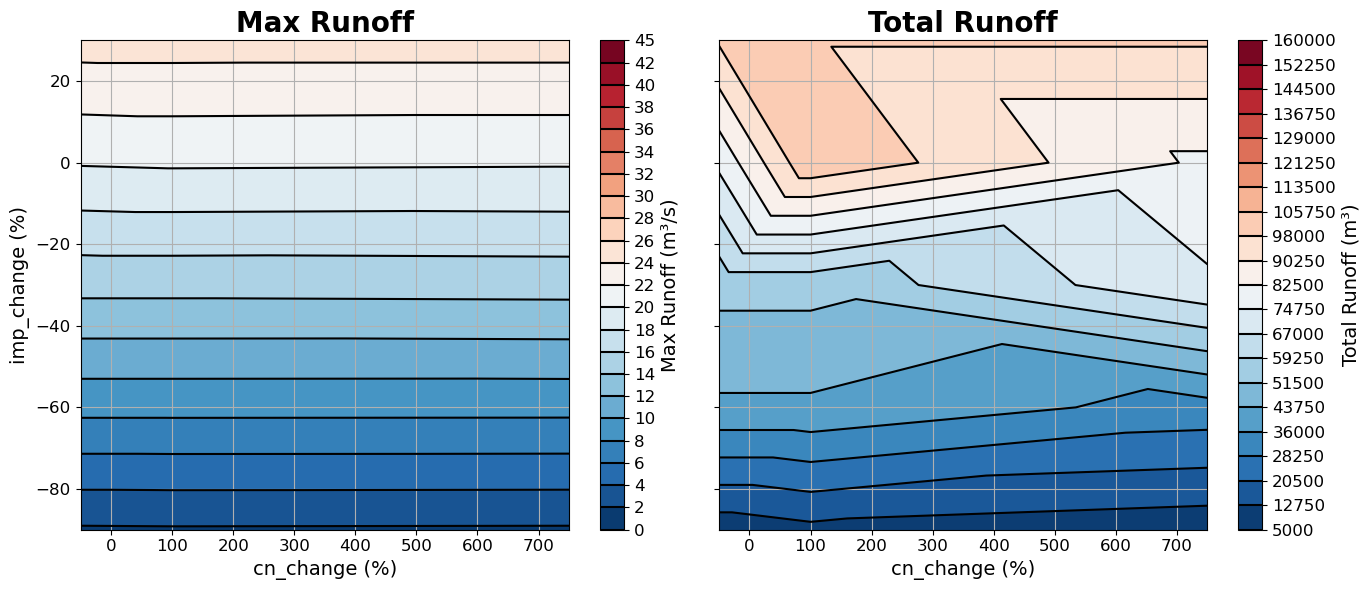

In [20]:
plot_response_surface(combined_df,'cn_change', 'imp_change', 'max_rainfall_change', 'storage_change')